In [ ]:
pip install --upgrade pip

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.gray()
!pip install opencv-python
import cv2
%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable


<Figure size 640x480 with 0 Axes>

# Convolutional Neural Networks mit Keras

Für sehr komplexe Datensätze, für die ein hohes Maß an Abstraktionsfähigkeit und Generalisierbarkeit aufgebracht werden muss, sind "klassische" Machine Learning Methoden meist nicht anwendbar. In vielen Bereichen können nur Deep Neural Networks mit einer großen Zahl an Parametern die nichtlinearen Relationen mit einer akzeptablen Genauigkeit abbilden. Dazu zählen vor allem Themen wie Bildklassifikation bzw. Objekterkennung. Die Klassifikation eines Bildes als Hund oder Katze stellt für einen Menschen keine Herausforderung dar, einem neuronalen Netz allerdings kann dies erst mit einer großen Anzahl an Trainingsbildern und einer sehr speziellen Netzarchitektur gelingen.

## Aufgabe 1: Bilder als 1-D Vektoren

In den vorherigen Übungen haben wir die Datensätze stets als 1-D Vektoren in einen Klassifikator gespeist. Dies könnte auch für Bilder ein erster Ansatz sein. Dazu wollen wir zunächst berechnen, wie viele Parameter ein Neuronales Netz benötigt, welches Bilder mit einer Größe von 28x28 Pixeln einließt und eine von 10 Klassen ausgibt. Die Anzahl an Parametern, die ein voll zusammenhängendes Neuronales Netz besitzt lässt sich berechnen mit $$N_P = \sum_{i=1}^{L-1} (n_i \cdot n_{i+1} + n_{i+1})$$ mit der Anzahl der Neuronen $n_i$ im $i$-ten Layer und einer Gesamtanzahl von Layern $L$. 

a) Wie viele Parameter besitzt ein Neuronales Netz, das zwei versteckte Layer besitzt mit der gleichen Größe wie die Input-Schicht? Schreibe eine Funktion in Python, die die Parameteranzahl ausrechnet. Sie soll als Argument eine Liste erhalten mit der Anzahl der Neuronen in jedem Layer. 

In [2]:
def parameters(layers: list):
    total_params = 0
    for i in range(len(layers) - 1):
        n_i = layers[i]
        n_i_plus_1 = layers[i+1]
        
        layer_params = (n_i * n_i_plus_1) + n_i_plus_1
        total_params += layer_params
        
    return total_params

In [3]:
layers = [784, 784, 784, 10]
parameters(layers)

1238730

b) Wie viele Parameter ergeben sich für ein Bild der Größe 200x200 mit dieser Methode? Wie verhält es sich bei einem Bild mit Full HD-Auflösung?

In [4]:
layers_200 = [40000, 40000, 40000, 10]
parameters(layers_200)

3200480010

In [5]:
layers_HD = [1920*1080, 1920*1080, 1920*1080, 10]
parameters(layers_HD)

8599658803210

Welche Probleme ergeben sich? Verändere hier nur die Anzahl der Neuronen in der Input-Schicht.

Bildverarbeitung liefert zu große Datenmengen (in Milliarden oder höher) und dazu würden reguläre NeuralNetworks nicht ausreichen, weil die Parameterzahl zu groß ist bzw. Gefahr Overfitting

## Aufgabe 2: Filter aus der Computer Vision

Im vorherigen Ansatz ist jeder Pixel aus dem eingespeisten Bild mit jedem Neuron aus dem nachfolgenden Layer verbunden. In Bildern sind Informationen jedoch häufig lokal zentriert. Daher ist ein nächster Ansatz, dass ein Neuron aus dem zweiten Layer nur Informationen zu benachbarten Pixeln im ursprünglichen Bild erhält. Dadurch kann die Anzahl der benötigten Parameter stark reduziert werden. 
In der klassischen Bildverarbeitung werden dafür meist Filter definiert, die über das Bild gelegt werden und so beispielsweise Kanten in einem Bild detektieren können. Diesen Ansatz möchten wir im Folgenden weiter untersuchen.

a) Lies das Bild ```digit_7.jpg``` mit der Größe $M$ x $M$ mit $M=28$ mithilfe von OpenCV (cv2) ein. Hinweis: Lies das Bild im Graustufen-Modus ein.
Lass dir das Bild anschließend in Juypter Notebook anzeigen (das funktioniert am besten mit der matplotlib-Bibliothek)

In [6]:
import cv2
import matplotlib.pyplot as plt

image_path = "digit_7.jpg"
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

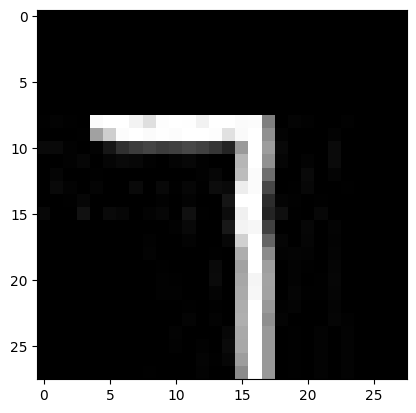

In [7]:
plt.imshow(image_gray, cmap='gray') 
plt.show()

Wir wenden im nächsten Schritt einen vorgefertigten Filter auf das Bild an. Der Filter ist eine 3x3 Matrix und wird anschaulich über das Bild "geschoben". Dabei wird erst das Hadamard-Produkt mit einem Teil des Bildes und dem Filter gebildet und anschließend die Summe der resultierenden Matrixelemente gebildet. Dieser Vorgang wird wiederholt, bis das ganze Bild abgedeckt ist.

<img src="convolution.png" style="width: 600px;"/>

b) Schreibe eine Funktion, die als Argumente das Bild und den Filter $N$ x $N$ jeweils als numpy Array erhält und die 2D Convolution davon ausgibt. Die 2D Convolution ist für unseren Fall gegeben als $$C_{kl} = \sum_{i, j=1}^{N} B_{i+k-1, j+l-1} \cdot F_{ij}$$ mit dem Filter $F$, dem Bild $B$ und dem Ergebnis der Convolution $C$ und funktioniert anschaulich wie oben beschrieben. Das Ergebnisbild hat die Dimension $M-N+1$ Hinweis: Benutze die eingebauten numpy Funktionen.

In [8]:
#image = np.array([[5,8,9],[3,2,1],[2,1,8]])
def twoD_convolution(image, filter):

    M = image.shape[0]
    N = filter.shape[0]
    
    output_dim = M - N + 1
    output_image = np.zeros((output_dim, output_dim))
    
    for k in range(output_dim):
        for l in range(output_dim):
            
            bild_anteil = image[k : k + N, l : l + N]
            
            hadamard_produkt = bild_anteil * filter
            
            convolution_result = np.sum(hadamard_produkt)
            
            output_image[k, l] = convolution_result
            
    return output_image

#output_image = twoD_convolution(image, filter_matrix)
#print(output_image)

In [9]:
filter_matrix = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])


c) Was kommt heraus, wenn du den Filter auf das Bild anwendest? Kannst du mit der gleichen Funktion auch horizontale Kanten hervorheben? Lass dir beide transformierte Bilder anzeigen!

In [10]:
res = twoD_convolution(image_gray, filter_matrix)

filter_hor = filter_matrix.T
res_hor = twoD_convolution(image_gray, filter_hor)

print(filter_matrix)
print(filter_hor)

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
[[ 1  1  1]
 [ 0  0  0]
 [-1 -1 -1]]


In [11]:
# Test your implementation
assert np.allclose(res, np.load('res_conv.npy'))
print('Test1 passed')


assert np.allclose(res_hor, np.load('res_conv_hor.npy'))
print('Test2 passed')

Test1 passed
Test2 passed


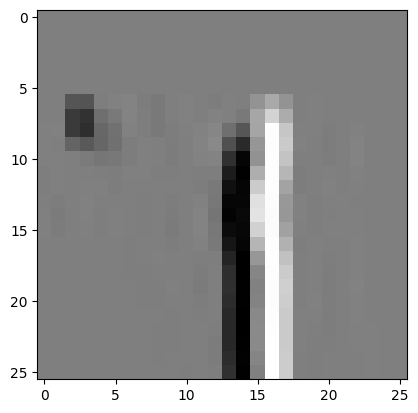

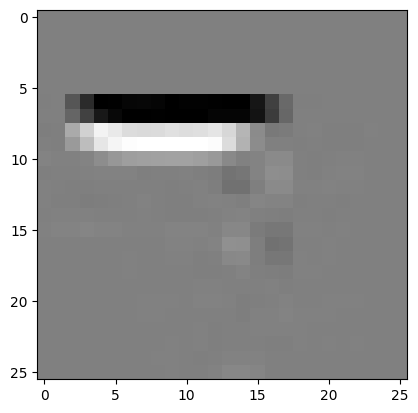

In [12]:
plt.imshow(res)
plt.show()

plt.imshow(res_hor)
plt.show()

d) Bis jetzt sind wir mit der Filtermatrix immer nur in Schritten von 1 vorangegangen. Um größere Texturen in hochaufgelösten Bildern zu erkennen, kann es aber sinnvoll sein die Schrittweite (englisch stride) auf einen größeren Wert zu setzen. Modifiziere obige Funktion und füge einen optionalen Parameter $s$ hinzu,  der die Schrittweite festlegt. Überprüfe dein Ergebnis mit $s=2$. Hinweis: Das Ergebnisbild hat nun die Dimension $\left\lfloor \frac{M-N}{s} \right\rfloor + 1$. 

In [13]:
def twoD_convolution_stride(image, filter, s):

    M = image.shape[0]
    N = filter.shape[0]
    
    output_dim = int((M - N) / s) + 1
    output_image = np.zeros((output_dim, output_dim))
    
    for k in range(0, M-N+1, s):
        for l in range(0, M-N+1, s):
            
            bild_anteil = image[k : k + N, l : l + N]
            
            hadamard_produkt = bild_anteil * filter
            
            convolution_result = np.sum(hadamard_produkt)
            
            output_image[k//s, l//s] = convolution_result
            
    return output_image

    
res = twoD_convolution_stride(image_gray, filter_matrix, 2)

In [14]:
assert np.allclose(res, np.load('res_conv_strided.npy'))
print('Test passed')

Test passed


Kanten lassen sich mit diesem Verfahren gut abbilden. Bei dieser Art der Covolution werden aber die Pixel am Rand des Bildes viel weniger stark gewichtet, als in der Mitte des Bildes. Um diesen Effekt abzuschwächen, kann das Bild mit Nullen an den Rändern künstlich vergrößert werden. Die eigentlichen Ränder des Bildes werden nun häufiger abgefahren und haben ein stärkeres Gewicht als vorher. Dieses Verfahren wird Padding genannt.


e) Modifiziere deine obige Funktion, um Padding zu implementieren. Frage dabei als optionalen Parameter ```padding=True/False``` ab, ob Padding durchgeführt werden soll. Die Dimension des Ergebnisbildes verändert sich nun zu $\left\lfloor \frac{M+2p-N}{s} \right\rfloor +1$ mit der Paddingbreite $p=\left\lfloor \frac{(s-1)\cdot M + N - s}{2} \right\rfloor$. Hinweis: Nutze die Funktion ```np.pad()```, wenn Padding durchgeführt werden soll.

In [15]:
def twoD_convolution_padding(image, filter, s, padding):

    M = image.shape[0]
    N = filter.shape[0]
    
    if padding:
        p = int(((s - 1) * M + N - s) / 2)
        image_to_use = np.pad(image, pad_width=p, mode='constant', constant_values=0)
        M_padded = image_to_use.shape[0]
    else:
        image_to_use = image
        M_padded = M
        p = 0

        
    output_dim = int(((M_padded - N) / s)) + 1
    output_image = np.zeros((output_dim, output_dim))
    

    output_k = 0
    for k in range(0, M_padded - N + 1, s):
        output_l = 0
        for l in range(0, M_padded - N + 1, s):
            
            bild_anteil = image_to_use[k : k + N, l : l + N]
            
            hadamard_produkt = bild_anteil * filter
            convolution_result = np.sum(hadamard_produkt)
            
            output_image[output_k, output_l] = convolution_result
            
            output_l += 1
        output_k += 1
            
    return output_image

    
res = twoD_convolution_padding(image_gray, filter_matrix, 2, True)

In [16]:
assert np.allclose(res, np.load('res_conv_padding.npy'))
print('Test passed')

Test passed


f) Modifiziere deine obige Funktion, um Dilatation zu ergänzen. Frage dabei als optionalen Parameter ```d``` ab, der angibt, wie viele Pixel im Filter übersprungen werden. Betrachte nur den Fall ```s=1``` und behalte das Padding bei. Die Dimension des Ergebnisbildes verändert sich nun zu $\left\lfloor \frac{M-N-(d-1)(N-1)+2p}{s} \right\rfloor +1$ mit der Paddingbreite $p=\left\lfloor \frac{N+(d-1)(N-1)-1}{2}\right\rfloor$. Teste deinen Code mit  ```d=2```.

In [19]:
def twoD_convolution_dilatation(image, filter, s, padding, d):

    M = image.shape[0]
    N = filter.shape[0]
    
    N_mod = N + (N - 1) * (d - 1)
    
    p = 0
    if padding:
        p = int(np.floor((N_mod - 1) / 2))
        
        image_to_use = np.pad(image, pad_width=p, mode='constant', constant_values=0)
        M_padded = image_to_use.shape[0]
        print(f"INFO: Padding p={p} angewendet. Effektive Filtergröße N_mod={N_mod}")
    else:
        image_to_use = image
        M_padded = M
        
    output_dim = int(np.floor((M_padded - N_mod) / s)) + 1
    output_image = np.zeros((output_dim, output_dim))
    
    output_k = 0
    for k in range(0, M_padded - N_mod + 1, s):
        output_l = 0
        for l in range(0, M_padded - N_mod + 1, s):

            bild_anteil = image_to_use[k : k + N_mod : d, l : l + N_mod : d]
            
            if bild_anteil.shape != filter.shape:
                continue 
            
            convolution_result = np.sum(bild_anteil * filter)
            
            output_image[output_k, output_l] = convolution_result
            
            output_l += 1
        output_k += 1
            
    return output_image

res = twoD_convolution_dilatation(image_gray, filter_matrix, 1, True, 2)

INFO: Padding p=2 angewendet. Effektive Filtergröße N_mod=5


In [20]:
assert np.allclose(res, np.load('res_conv_dilatation.npy'))
print('Test passed')

Test passed


## Aufgabe 3: CNNs mit Keras und FashionMNIST

Im vorherigen Beispiel haben wir den anzuwendenden Filter vorgegeben. Der Grundgedanke eines Convolutional Neural Networks (CNN) ist es nun solche Filter via Backpropagation zu lernen, ganz analog zu einem vollständig zusammenhängenden neuronalen Netz. In jedem Convolutional Layer des Netzes wird dann nicht mehr eine große Gewichtsmatrix $W$ gelernt, sondern mehrere kleine Filtermatrizen. Die Matrizen sollen möglichst verschiedene Eigenschaften eines Bildes herausfiltern, die dann im nächsten Layer weiterverarbeitet werden können.

In vielen Fällen ist der Input des Bildes keine einfache $N \times N$-Matrix, sondern besitzt drei Farb-Kanäle (RGB). Ein Filter wird dann auf alle drei Matrizen gleichzeitig angewendet und die Zahlen werden für jeden Eintrag des Ergebnisses addiert. Auf diese Weise kann ein Convolutional Layer auch mit Inputs umgehen, die aus einem Layer mit mehreren Filtern kommen. Ein schemtischer Aufbau eines CNNs sieht dann ungefähr so aus:

<img src="Typical_cnn.png" alt="CNN" style="width: 600px;"/>


Quelle:[https://jaai.de/convolutional-neural-networks-cnn-aufbau-funktion-und-anwendungsgebiete-1691/](https://jaai.de/convolutional-neural-networks-cnn-aufbau-funktion-und-anwendungsgebiete-1691/)

Das Subsampling wird in Teilaufgabe b) nochmal genauer erläutert.



Im folgenden möchten wir ganz konkret einen Bilddatensatz einlesen und mittels TensorFlow/Keras ein CNN trainieren.

a) Importiere von ```tensorflow.keras.datasets``` den FashionMNIST-Datensatz und lies ihn als Traings- und Testdatensatz aufgeteilt ein. Lass dir einzelne Bilder des Datensatzes plotten. Was ist auf den Bildern dargestellt? Wie viele Klassen gibt es? Normiere die Pixelwerte der Bilder auf einen Wert zwischen 0 und 1.

In [2]:
import sys
print(sys.executable)

/Applications/Xcode.app/Contents/Developer/usr/bin/python3


In [3]:
!/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip uninstall numpy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [4]:
!/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install numpy==1.26.4

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


2025-12-14 17:13:28.921670: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/alimounir/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape des Trainings-Input-Arrays: (60000, 28, 28)
Anzahl der Trainingsbeispiele: 60000


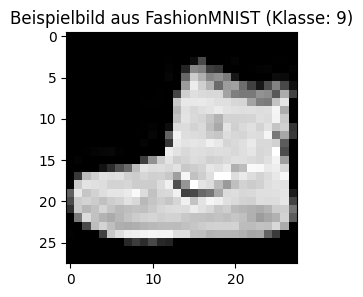

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Shape des Trainings-Input-Arrays:", x_train.shape)
print("Anzahl der Trainingsbeispiele:", x_train.shape[0])

plt.figure(figsize=(3, 3))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Beispielbild aus FashionMNIST (Klasse: {y_train[0]})")
plt.show()

In [3]:
num_classes = np.unique(y_train).size
print(f"\nAnzahl der Klassen: {num_classes}")

max_pixel_value = x_train.max()
print(f"Maximaler ursprünglicher Pixelwert: {max_pixel_value}")


x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f"Maximaler normierter Pixelwert (Training): {x_train_norm.max()}")
print(f"Minimaler normierter Pixelwert (Training): {x_train_norm.min()}")


Anzahl der Klassen: 10
Maximaler ursprünglicher Pixelwert: 255
Maximaler normierter Pixelwert (Training): 1.0
Minimaler normierter Pixelwert (Training): 0.0


b) Für die nächste Teilaufgabe muss dem Input künstlich eine Dimension hinzugefügt werden. Wende auf ```x_train``` und ```x_test``` jeweils ```np.reshape(-1,28, 28, 1)``` an.

In [5]:
x_train_reshaped = x_train_norm.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_norm.reshape(-1, 28, 28, 1)

print(f"Ursprüngliche x_train Shape: {x_train_norm.shape}")
print(f"Neue x_train Shape:         {x_train_reshaped.shape}")
print(f"Ursprüngliche x_test Shape:  {x_test_norm.shape}")
print(f"Neue x_test Shape:           {x_test_reshaped.shape}")

Ursprüngliche x_train Shape: (60000, 28, 28)
Neue x_train Shape:         (60000, 28, 28, 1)
Ursprüngliche x_test Shape:  (10000, 28, 28)
Neue x_test Shape:           (10000, 28, 28, 1)


Im nächsten Schritt wollen wir ein CNN mit Keras aufbauen. Eine Abwandlung der LeNet-Architektur bietet dafür einen guten Anfang. Der Aufbau ist:
1. Convolutional Layer mit 6 Filtern und einer Filtergröße von 3x3.
2. MaxPooling Layer
3. Convolutional Layer mit 16 Filtern und einer Filtergröße von 3x3.
4. MaxPooling Layer
5. Dense Layer mit 120 Neuronen.
6. Dense Layer mit 84 Neuronen.
7. Dense Layer mit 10 Neuronen und der Softmax-Aktivierungsfunktion.

In jedem Layer (bis auf die letzte) soll die ReLu-Aktivierungsfunktion verwendet werden. Ein MaxPooling Layer konzentrieren die Informationen des convolutional Layer, indem in jedem 2x2 Teilbereich seines Inputs das Maximum findet. Dadurch werden Höhe und Breite des Inputs jeweils halbiert.

<img src="max_pooling.png" style="width: 300px;"/>


c) Importiere ```Conv2D, MaxPooling2D``` und ```Dense``` aus ```tf.keras.layers``` und baue obige Architektur nach. Lass dir dein Modell mit ```.summary()``` ausgeben. Hinweis: Zwischen 4. und 5. muss das Array in die Form eines 1-D Vektors gebracht werden, da ```Dense``` nicht mit 2-D-Eingaben arbeiten kann.


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(filters=6, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(units=120, activation='relu'))

model.add(Dense(units=84, activation='relu'))

model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 16)     │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,074 (234.66 KB)

 Trainable params: 60,074 (234.66 KB)

 Non-trainable params: 0 (0.00 B)

d) Um das Modell bereit fürs Training zu machen, wird die ```.compile()```-Methode verwendet. Dabei sollte noch die verwendete Verlustfunktion, sowie der genutze Optimierer angegeben werden. Wähle hierfür die ```sparse_categorical_crossentropy``` bzw. den Adam-Optimierer. Nutze die Accuracy als Qualitätsmetrik. Trainiere nun das Modell mit einer Batchgröße von 64 über 10 Epochen.  

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_reshaped, y_train, epochs=10, batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7070 - loss: 0.8421
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8580 - loss: 0.3924
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8759 - loss: 0.3384
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8828 - loss: 0.3174
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8937 - loss: 0.2891
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8978 - loss: 0.2709
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9050 - loss: 0.2560
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9093 - loss: 0.2425
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9130 - loss: 0.2332
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9160 - loss: 0.2217


e) Die Methode ``model.fit()`` gibt ein dictionary zurück, welches Informationen über das erfolgte Training enthält. Speichere die Accuracy von Trainings- und Testdaten und plotte sie über die Epochen für unterschiedliche Batch-Größen.

In [10]:
batch_sizes = [32, 64, 128]
histories = {}

for bs in batch_sizes:
    print(f"\n--- Training für Batch-Größe: {bs} ---")
    
    history = model.fit(
        x_train_reshaped, 
        y_train, 
        epochs=10, 
        batch_size=bs,
        validation_data=(x_test_reshaped, y_test),
        verbose=1
    )
    histories[bs] = history


--- Training für Batch-Größe: 32 ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9123 - loss: 0.2368 - val_accuracy: 0.8915 - val_loss: 0.3029
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9176 - loss: 0.2196 - val_accuracy: 0.8981 - val_loss: 0.2797
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9206 - loss: 0.2059 - val_accuracy: 0.8972 - val_loss: 0.2816
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9292 - loss: 0.1887 - val_accuracy: 0.8937 - val_loss: 0.2957
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9294 - loss: 0.1833 - val_accuracy: 0.9006 - val_loss: 0.2916
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9338 - loss: 0.1764 - val_accuracy: 0.9014 - val_loss: 0.2966
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9367 - loss: 0.1666 - val_accuracy: 0.8978 - val_loss: 0.3129
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━

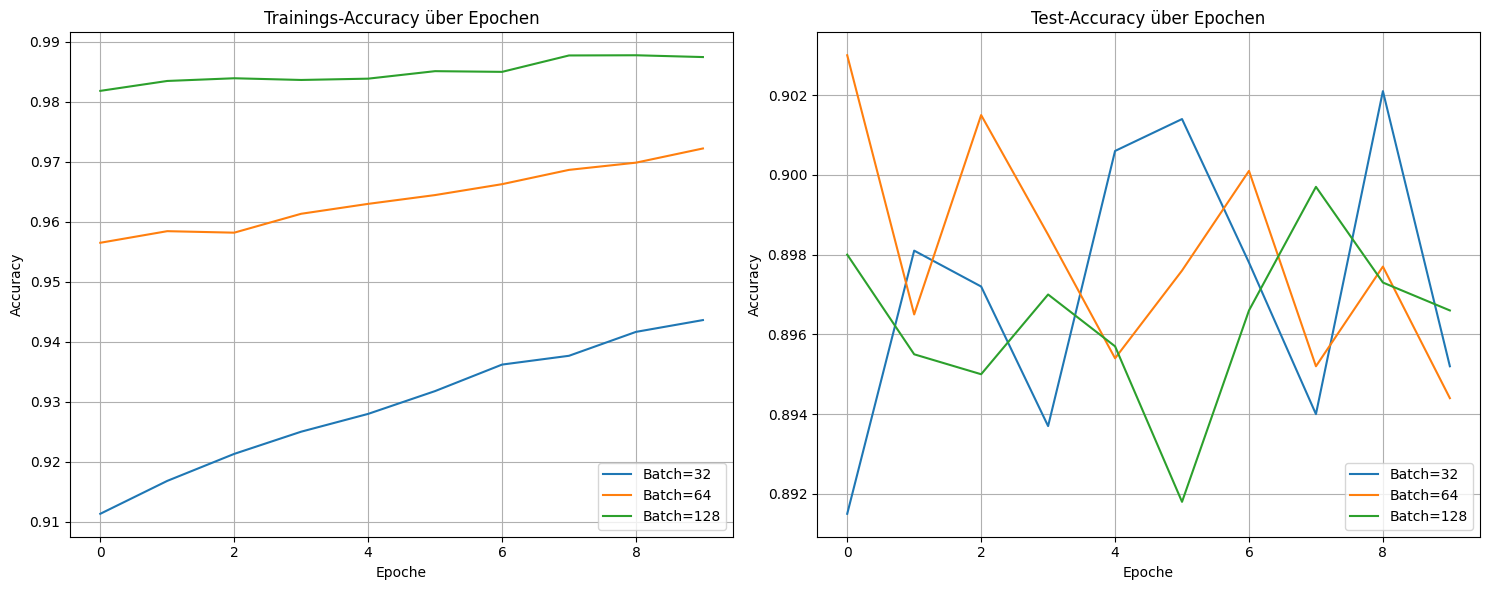

In [11]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for bs, history in histories.items():
    plt.plot(history.history['accuracy'], label=f'Batch={bs}')
    
plt.title('Trainings-Accuracy über Epochen')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for bs, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'Batch={bs}')
    
plt.title('Test-Accuracy über Epochen')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()